In [5]:
import sys
sys.path.append("../..")

import json
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay

from src.utils import SEED, CLASES, REPORTS_DIR, fijar_semilla, cargar_dataset, split_estratificado, evaluar_modelo, guardar_modelo
from src.preprocessing import descartar_columnas
from src.model_ordinal import entrenar, predecir

fijar_semilla(SEED)


In [6]:
df = descartar_columnas(cargar_dataset())
X_train, X_val, X_test, y_train, y_val, y_test = split_estratificado(df, excluir=["price_clean", "id"])
X_train.shape, X_val.shape, X_test.shape

((43131, 22), (9243, 22), (9243, 22))

In [7]:
modelo = entrenar(X_train, y_train, alpha=1.0)
metricas_val = evaluar_modelo(y_val, predecir(modelo, X_val))
{k: v for k, v in metricas_val.items() if k != "matriz_confusion"}

c:\Users\willi\OneDrive\Documentos\GitHub\AirPrice\.venv\Lib\site-packages\mord\threshold_based.py:132: OptimizeWarning: Unknown solver options: disp
  sol = optimize.minimize(obj_margin, x0, method='L-BFGS-B',


{'accuracy': 0.621010494428216,
 'balanced_accuracy': 0.6207184154638032,
 'f1_macro': 0.6233841239982553,
 'f1_weighted': 0.6237026902179897}

In [8]:
resultados = []
for alpha in [0.01, 0.1, 1, 10, 100]:
    m = entrenar(X_train, y_train, alpha=alpha)
    met = evaluar_modelo(y_val, predecir(m, X_val))
    resultados.append({"alpha": alpha, "f1_macro": met["f1_macro"], "balanced_accuracy": met["balanced_accuracy"]})

resultados = pd.DataFrame(resultados).sort_values("f1_macro", ascending=False)
mejor_alpha = resultados.iloc[0]["alpha"]
display(resultados)

modelo = entrenar(X_train, y_train, alpha=mejor_alpha)
print("Umbrales ordinales aprendidos (theta):", modelo.named_steps["modelo"].theta_)

c:\Users\willi\OneDrive\Documentos\GitHub\AirPrice\.venv\Lib\site-packages\mord\threshold_based.py:132: OptimizeWarning: Unknown solver options: disp
  sol = optimize.minimize(obj_margin, x0, method='L-BFGS-B',
c:\Users\willi\OneDrive\Documentos\GitHub\AirPrice\.venv\Lib\site-packages\mord\threshold_based.py:132: OptimizeWarning: Unknown solver options: disp
  sol = optimize.minimize(obj_margin, x0, method='L-BFGS-B',
c:\Users\willi\OneDrive\Documentos\GitHub\AirPrice\.venv\Lib\site-packages\mord\threshold_based.py:132: OptimizeWarning: Unknown solver options: disp
  sol = optimize.minimize(obj_margin, x0, method='L-BFGS-B',
c:\Users\willi\OneDrive\Documentos\GitHub\AirPrice\.venv\Lib\site-packages\mord\threshold_based.py:132: OptimizeWarning: Unknown solver options: disp
  sol = optimize.minimize(obj_margin, x0, method='L-BFGS-B',
c:\Users\willi\OneDrive\Documentos\GitHub\AirPrice\.venv\Lib\site-packages\mord\threshold_based.py:132: OptimizeWarning: Unknown solver options: disp
  sol 

,alpha,f1_macro,balanced_accuracy
1,0.10,0.624008,0.621370
0,0.01,0.623911,0.621261
2,1.00,0.623384,0.620718
3,10.00,0.623283,0.620505
4,100.00,0.619690,0.616502


c:\Users\willi\OneDrive\Documentos\GitHub\AirPrice\.venv\Lib\site-packages\mord\threshold_based.py:132: OptimizeWarning: Unknown solver options: disp
  sol = optimize.minimize(obj_margin, x0, method='L-BFGS-B',


Umbrales ordinales aprendidos (theta): [-0.84727967  1.63875896  3.90181003]


{'accuracy': 0.6254, 'balanced_accuracy': 0.6252, 'f1_macro': 0.6279, 'f1_weighted': 0.6282}


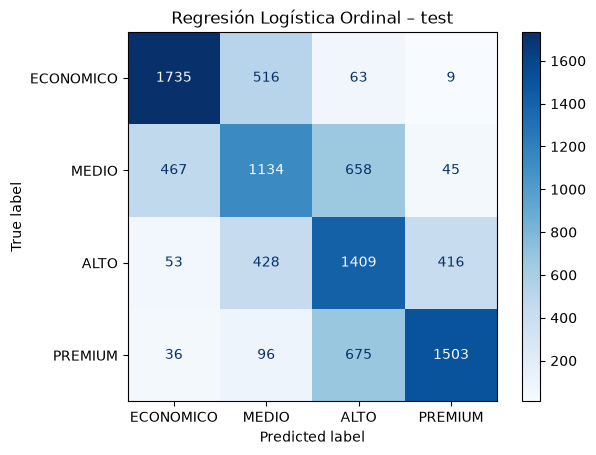

WindowsPath('C:/Users/willi/OneDrive/Documentos/GitHub/AirPrice/models/ordinal_logistic.joblib')

In [9]:
metricas = evaluar_modelo(y_test, predecir(modelo, X_test))
print({k: round(v, 4) for k, v in metricas.items() if k != "matriz_confusion"})

ConfusionMatrixDisplay(metricas["matriz_confusion"], display_labels=CLASES).plot(cmap="Blues")
plt.title("Regresión Logística Ordinal – test")
plt.savefig(REPORTS_DIR / "ordinal_logistic_confusion.png", bbox_inches="tight")
plt.show()

with open(REPORTS_DIR / "ordinal_logistic_metricas.json", "w") as f:
    json.dump({"alpha": float(mejor_alpha), **{k: float(v) for k, v in metricas.items() if k != "matriz_confusion"}}, f, indent=2)

guardar_modelo(modelo, "ordinal_logistic")

Conclusión. La Regresión Logística Ordinal (alpha=0.1) obtuvo F1-macro de 0.628 y Balanced Accuracy de 0.625 en test, similar a validación, por lo que no hay sobreajuste. El valor de alpha casi no influyó. Las clases extremas se predicen mejor (ECONOMICO 75 %, PREMIUM 65 %) y MEDIO es la más difícil (49 %). El 91 % de los errores ocurre entre clases vecinas, lo que muestra que el modelo respeta el orden de los rangos de precio. Esta es la línea base lineal para comparar con Random Forest, XGBoost y LightGBM.